**# Telco Customer Churn Prediction**

**## Project Overview**

This notebook presents an end-to-end machine learning workflow for predicting customer churn. The project includes data loading, data cleaning, exploratory data analysis, feature engineering, model development, evaluation, and business insights.

**Objective:** Identify customers who are likely to leave the telecom service and understand the key factors influencing churn.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**## 1. Data Loading**

The Telco Customer Churn dataset is loaded and prepared for analysis. This dataset contains customer demographics, account information, subscribed services, and churn status.

In [2]:
import pandas as pd
df=pd.read_csv('/content/drive/MyDrive/Customer-Churn-Prediction/data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

**## 2. Initial Dataset Exploration**

The following steps help understand the dataset structure, dimensions, available features, and data quality before preprocessing.

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

In [5]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


**## 3.Data Cleaning and Preprocessing**

Before building machine learning models, missing values, incorrect data types, and unnecessary columns are handled to prepare the dataset.

In [11]:
df[df['TotalCharges']==' ']

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [12]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')

In [13]:
df['TotalCharges']=df['TotalCharges'].fillna(0)

In [14]:
df["TotalCharges"].dtype

dtype('float64')

In [15]:
df.drop('customerID',axis=1,inplace=True)

**## 4. Target Variable Analysis**

The target variable **Churn** represents whether a customer has discontinued the service. Understanding its distribution helps identify class imbalance.

In [16]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [17]:
df['Churn'].value_counts(normalize=True)*100

,proportion
Churn,
No,73.463013
Yes,26.536987


**Check Churn Distribution**

**## 5. Exploratory Data Analysis (EDA)**

EDA is performed to discover patterns and relationships between customer attributes and churn behavior.

**How many customers are leaving the company compared to those who continue using the service?**

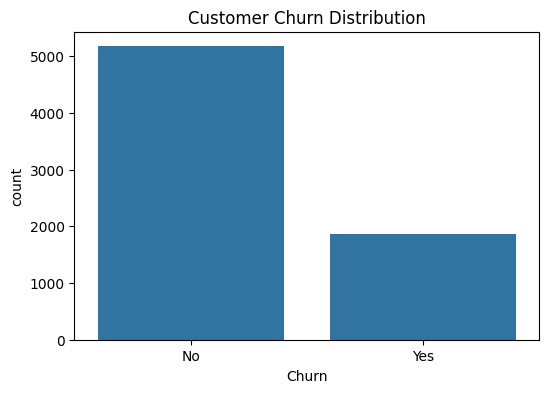

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6,4))
sns.countplot(data=df,x='Churn')
plt.title('Customer Churn Distribution')
plt.show()

**Around 26.5% of customers have churned, while 73.5% remain active. This indicates a class imbalance, where non-churned customers are the majority. Therefore, model evaluation should focus on metrics like recall, F1-score, and ROC-AUC rather than accuracy alone.**

**How does the type of contract influence customer churn, and which contract customers are more likely to leave the company?**

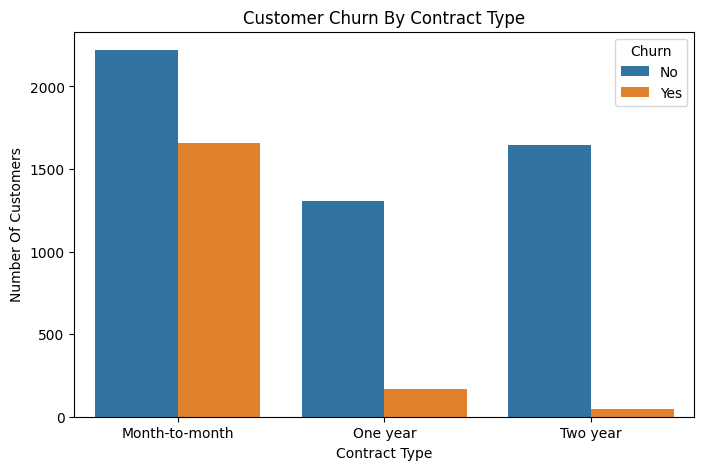

In [19]:
plt.figure(figsize=(8,5))
sns.countplot(data=df,x='Contract',hue='Churn')
plt.title('Customer Churn By Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number Of Customers')
plt.show()

**Customers with month-to-month contracts show significantly higher churn compared to customers with one-year and two-year contracts. Long-term contracts appear to improve customer retention because customers have a stronger commitment to the service.**

**Do customers with shorter tenure have a higher likelihood of churning compared to long-term customers?**

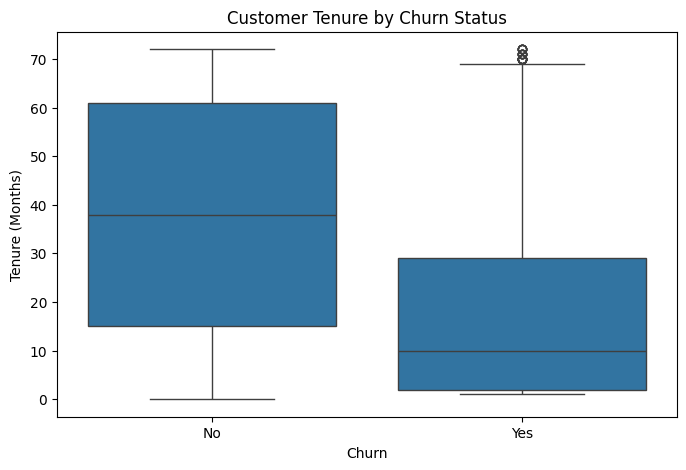

In [20]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Customer Tenure by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

**Customers who churn generally have much shorter tenures than customers who remain with the company. This suggests that new customers are at a significantly higher risk of leaving, making customer retention efforts especially important during the early months of service.**

**Do customers who pay higher monthly charges churn more often?**

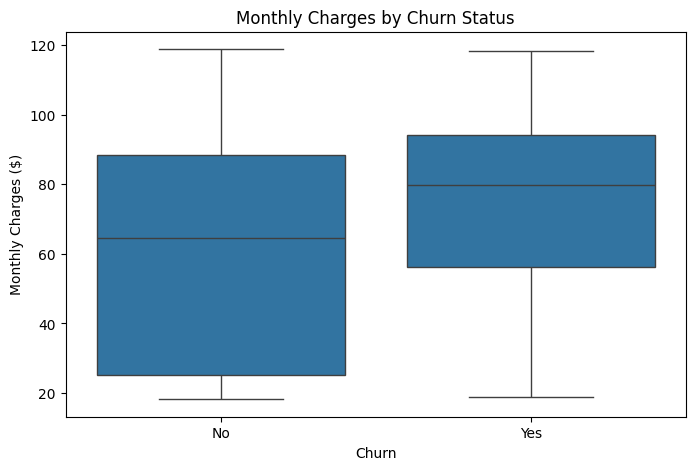

In [21]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df,x='Churn',y='MonthlyCharges')
plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges ($)")

plt.show()

**Customers who churn generally have higher monthly charges than customers who remain with the company. This suggests that higher service costs may increase the likelihood of churn, especially if customers do not perceive sufficient value for the price they pay. The company should evaluate pricing strategies, improve service quality, or provide loyalty benefits for customers on higher-priced plan**

**Does the type of internet service influence customer churn?**

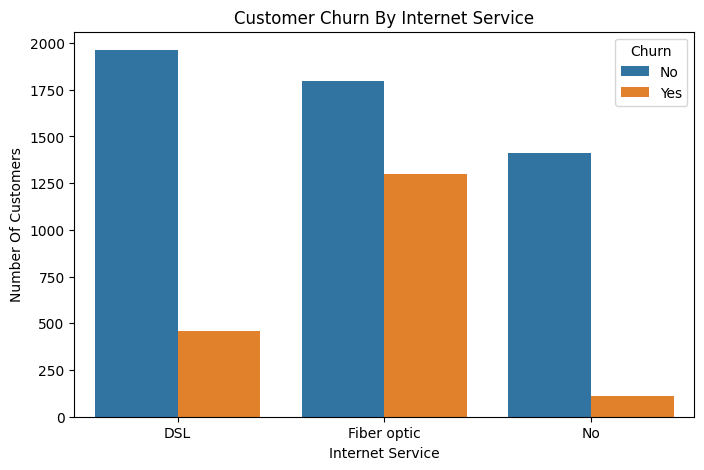

In [22]:
plt.figure(figsize=(8,5))
sns.countplot(data=df,x='InternetService',hue='Churn')
plt.title('Customer Churn By Internet Service')
plt.xlabel('Internet Service')
plt.ylabel('Number Of Customers')
plt.show()

**Customers using Fiber Optic internet exhibit the highest churn rate. Although Fiber Optic offers faster internet speeds, customers may have higher expectations regarding service quality or pricing. The company should investigate customer satisfaction, pricing, and service reliability for Fiber Optic plans to improve retention.**

**Does the customer's payment method affect the likelihood of churn?**

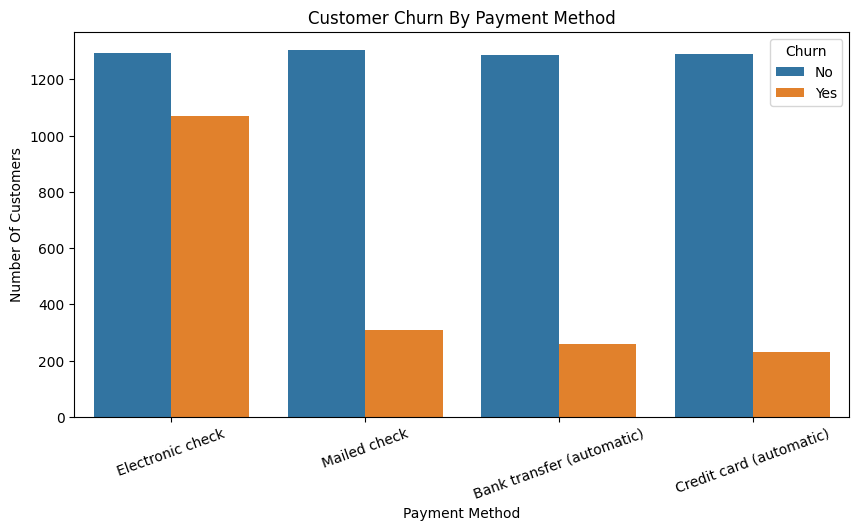

In [23]:
plt.figure(figsize=(10,5))
sns.countplot(data=df,x='PaymentMethod',hue='Churn')
plt.title('Customer Churn By Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Number Of Customers')
plt.xticks(rotation=20)
plt.show()

**Calculating Churn Percentage**

In [24]:
payment_churn=(df.groupby('PaymentMethod')['Churn'].value_counts(normalize=True).mul(100).rename('Percentage').reset_index())
payment_churn

,PaymentMethod,Churn,Percentage
0,Bank transfer (automatic),No,83.290155
1,Bank transfer (automatic),Yes,16.709845
2,Credit card (automatic),No,84.756899
3,Credit card (automatic),Yes,15.243101
4,Electronic check,No,54.714588
5,Electronic check,Yes,45.285412
6,Mailed check,No,80.893300
7,Mailed check,Yes,19.106700


**Plotting Percentage Graph**

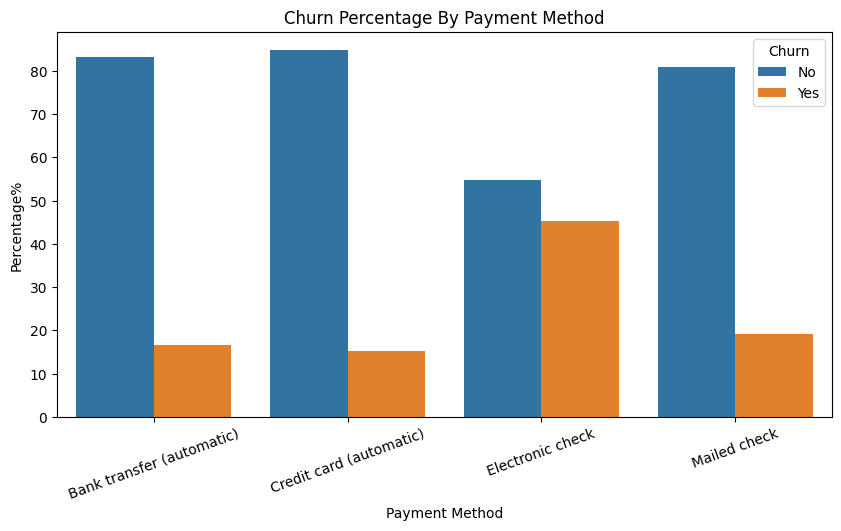

In [25]:
plt.figure(figsize=(10,5))
sns.barplot(data=payment_churn,x='PaymentMethod',y='Percentage',hue='Churn')
plt.title('Churn Percentage By Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Percentage%')
plt.xticks(rotation=20)
plt.show()

**Business Insight**

**Customers who use electronic checks have the highest churn rate (approximately 45%), significantly higher than customers using automatic payment methods. In contrast, customers paying through automatic bank transfers or credit cards exhibit much lower churn rates, suggesting that automatic payment methods are associated with better customer retention.**


**Business Recommendation**

**The company should encourage customers using electronic checks to switch to automatic payment methods by offering incentives such as discounts, cashback, or loyalty rewards. This may improve customer retention and reduce churn**

**Are customers without technical support more likely to churn?**

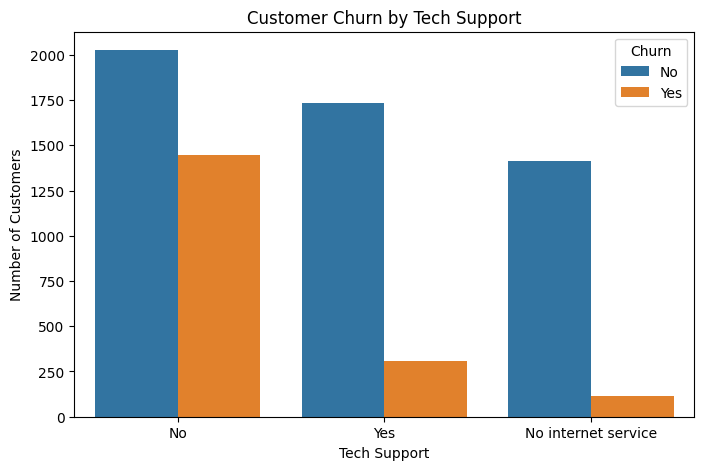

In [26]:
#Countplot
plt.figure(figsize=(8,5))
sns.countplot(data=df,x='TechSupport',hue='Churn')
plt.title("Customer Churn by Tech Support")
plt.xlabel("Tech Support")
plt.ylabel("Number of Customers")

plt.show()


**Churn Percentage And Percentage Barplot**

           TechSupport Churn  Percentage%
0                   No    No    58.364526
1                   No   Yes    41.635474
2  No internet service    No    92.595020
3  No internet service   Yes     7.404980
4                  Yes    No    84.833659
5                  Yes   Yes    15.166341


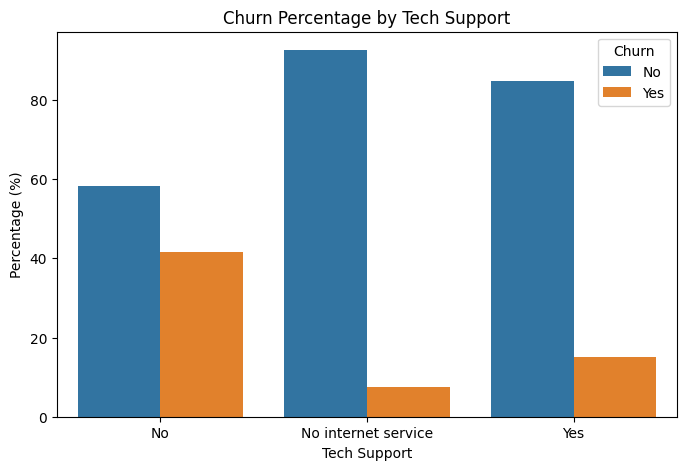

In [27]:
tech_churn=(df.groupby('TechSupport')['Churn'].value_counts(normalize=True).mul(100).rename('Percentage%').reset_index())
print(tech_churn)
plt.figure(figsize=(8,5))
sns.barplot(data=tech_churn,x='TechSupport',y='Percentage%',hue='Churn')
plt.title("Churn Percentage by Tech Support")
plt.xlabel("Tech Support")
plt.ylabel("Percentage (%)")

plt.show()


**Business Insight**

**Customers without Tech Support have a significantly higher churn rate (41.64%) compared to customers who subscribe to Tech Support (15.17%). This suggests that providing effective technical support is associated with higher customer satisfaction and improved customer retention.**

**Business Recommendation**

**The company should encourage customers to subscribe to Tech Support services and ensure high-quality technical assistance. Offering free trial periods or bundling Tech Support with premium plans could help reduce churn among customers who currently do not receive support.**

**Does subscribing to online security services reduce customer churn?**

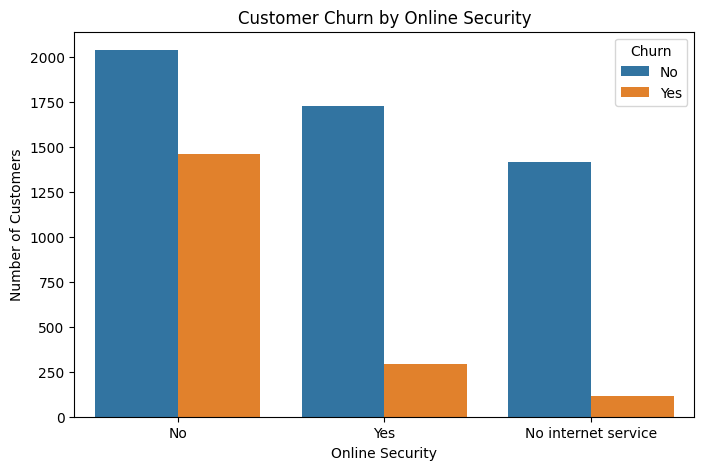

In [28]:
#countplot
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="OnlineSecurity",
    hue="Churn"
)

plt.title("Customer Churn by Online Security")
plt.xlabel("Online Security")
plt.ylabel("Number of Customers")

plt.show()

**Percentage Table And Percentage Plot**

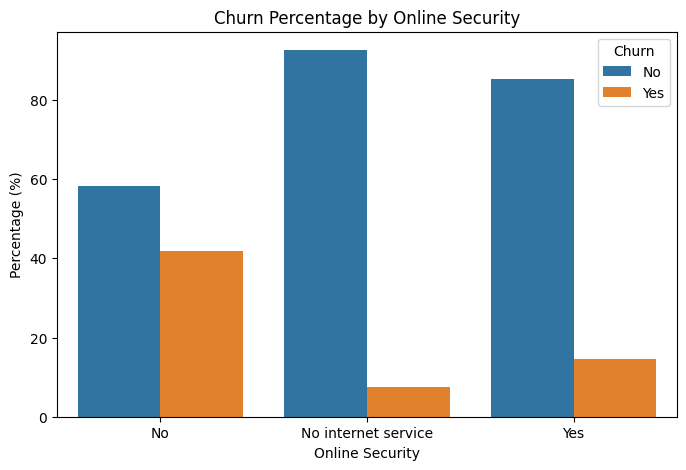

In [29]:
security_churn = (
    df.groupby("OnlineSecurity")["Churn"]
      .value_counts(normalize=True)
      .mul(100)
      .rename("Percentage")
      .reset_index()
)

security_churn
plt.figure(figsize=(8,5))

sns.barplot(
    data=security_churn,
    x="OnlineSecurity",
    y="Percentage",
    hue="Churn"
)

plt.title("Churn Percentage by Online Security")
plt.xlabel("Online Security")
plt.ylabel("Percentage (%)")

plt.show()

**Business Insight**

**Customers without Online Security have a significantly higher churn rate (41.77%) than customers who subscribe to Online Security (14.61%). This indicates that customers who use additional value-added services are more likely to remain with the company, suggesting a strong association between service adoption and customer retention.**

**Business Recommendation**
**The company should encourage customers to adopt Online Security services through promotional offers, bundled packages, or free trial periods. Increasing adoption of value-added services may improve customer engagement and help reduce churn.**

**## 6. Feature Preparation for Machine Learning**

The dataset is transformed into input features (X) and target labels (y) for model training.

In [30]:
X=df.drop('Churn',axis=1)
y=df['Churn']

In [31]:
print(X.shape)
print(y.shape)

(7043, 19)
(7043,)


In [32]:
y=y.map({'No':0,'Yes':1})

In [33]:
y.head()

,Churn
0,0
1,0
2,1
3,0
4,1


In [34]:
X=pd.get_dummies(X,drop_first=True)

In [35]:
print(X.shape)

(7043, 30)


In [36]:
X.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


**Correlation Analysis Preparation**

In [37]:
corr=X.copy()
corr['Churn']=y
correlation_matrix=corr.corr()

**Relationship Between Customer Features and Churn**

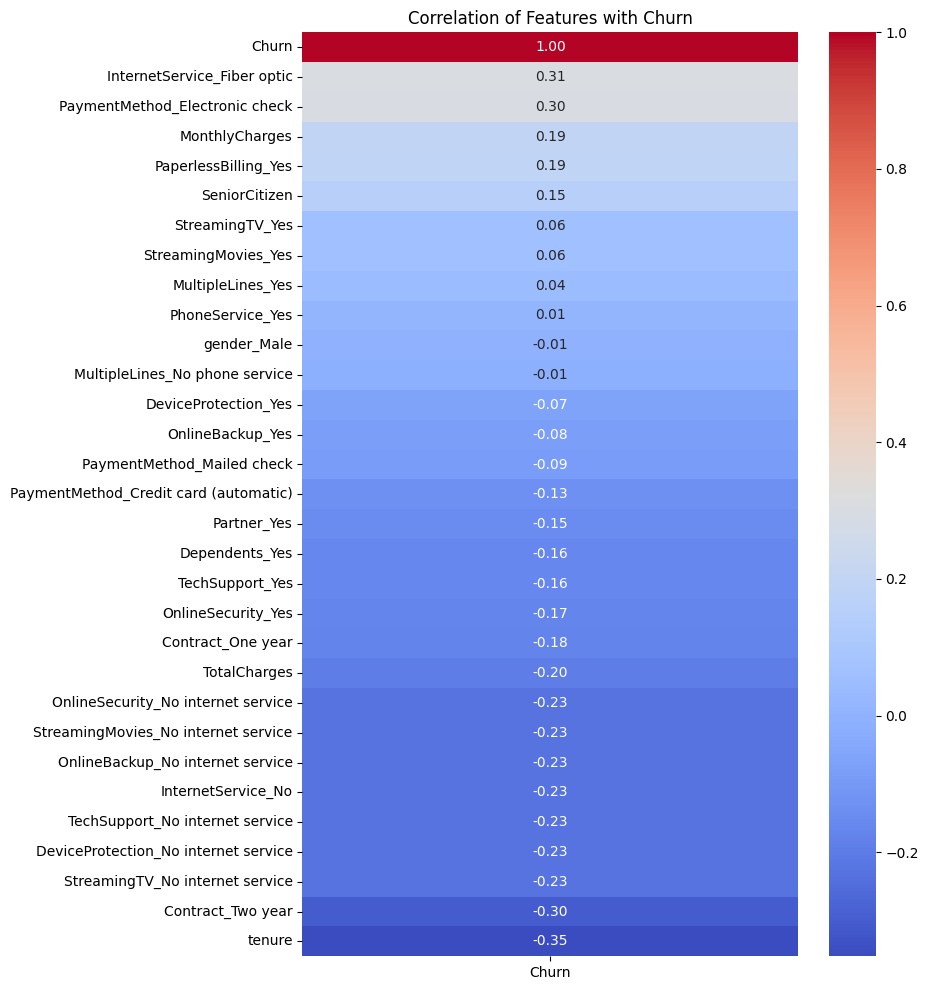

In [38]:
corr_with_churn=correlation_matrix['Churn'].sort_values(ascending=False)
plt.figure(figsize=(8,12))
sns.heatmap(corr_with_churn.to_frame(),annot=True,cmap='coolwarm',fmt='.2f')
plt.title("Correlation of Features with Churn")
plt.show()

**Business Insight**

**Customers using Fiber Optic internet, Electronic Check payments, and paying higher monthly charges are associated with higher churn. These customer segments may require targeted retention strategies.**

**Customers with longer tenure, long-term contracts, and additional services such as Online Security and Tech Support are associated with lower churn, suggesting that customer engagement and commitment play important roles in retention.**

Correlation analysis showed that customer tenure (-0.35) and two-year contracts (-0.30) were the strongest negative predictors of churn, indicating that long-term customers are more likely to stay. On the other hand, Fiber Optic internet (0.31) and Electronic Check payment (0.30) showed the strongest positive associations with churn, suggesting that these customer groups are at higher risk of leaving.

**## 7. Feature Encoding, Scaling, and Train-Test Split**

Categorical variables are converted into numerical format using encoding techniques, and numerical features are standardized using feature scaling. The dataset is then divided into training and testing sets to prepare the data for machine learning model development and evaluation.

In [39]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)


In [40]:
print(X_train.shape)
print(X_test.shape)

print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(5634, 30)
(1409, 30)
Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64
Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


In [41]:
numerical_features=['tenure','MonthlyCharges','TotalCharges']


In [42]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaler.fit(X_train[numerical_features])
X_train[numerical_features]=scaler.transform(X_train[numerical_features])
X_test[numerical_features]=scaler.transform(X_test[numerical_features])
X_train[numerical_features].describe()


,tenure,MonthlyCharges,TotalCharges
count,5.634000e+03,5.634000e+03,5.634000e+03
mean,-1.008935e-17,-2.402527e-16,2.522338e-17
std,1.000089e+00,1.000089e+00,1.000089e+00
min,-1.322329e+00,-1.544028e+00,-1.008922e+00
25%,-9.559779e-01,-9.711977e-01,-8.321009e-01
50%,-1.418632e-01,1.848336e-01,-3.968446e-01
75%,9.164859e-01,8.319124e-01,6.741944e-01
max,1.608483e+00,1.785939e+00,2.801869e+00


In [43]:
bool_cols = X_train.select_dtypes(include='bool').columns

X_train[bool_cols] = X_train[bool_cols].astype(int)
X_test[bool_cols] = X_test[bool_cols].astype(int)

In [44]:
print(X_train.shape)
print(X_test.shape)

X_train.head()

(5634, 30)
(1409, 30)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
3738,0,0.102371,-0.521976,-0.262257,1,0,0,0,1,0,...,0,1,0,1,0,0,0,0,1,0
3151,0,-0.711743,0.337478,-0.503635,1,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,1
4860,0,-0.793155,-0.809013,-0.749883,1,1,1,0,1,0,...,0,0,0,0,0,1,0,0,0,1
3867,0,-0.263980,0.284384,-0.172722,0,1,0,1,0,0,...,0,1,0,1,0,1,1,1,0,0
3810,0,-1.281624,-0.676279,-0.989374,1,1,1,1,0,0,...,0,0,0,0,0,0,0,0,1,0


**## 8. Logistic Regression Model**

Logistic Regression is used as a baseline classification model because it provides an interpretable approach for binary churn prediction.

**logistic Regression Model**

In [45]:
from sklearn.linear_model import LogisticRegression
log_model=LogisticRegression(random_state=42)
log_model.fit(X_train,y_train)
y_pred=log_model.predict(X_test)


In [46]:
y_prob=log_model.predict_proba(X_test)[:,1]
print(y_prob)

[0.0464133  0.68419325 0.0603014  ... 0.1530544  0.0044152  0.00642766]


In [47]:
print("Training Accuracy:", log_model.score(X_train, y_train))
print("Testing Accuracy:", log_model.score(X_test, y_test))

Training Accuracy: 0.8058217962371317
Testing Accuracy: 0.8062455642299503


**Performance Metrics of Logistic Regression**

In [48]:
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix,classification_report)

In [49]:
accuracy_log = accuracy_score(y_test, y_pred)
precision_log = precision_score(y_test, y_pred)
recall_log = recall_score(y_test, y_pred)
f1_log = f1_score(y_test, y_pred)
roc_auc_log = roc_auc_score(y_test, y_prob)

print(f"Accuracy : {accuracy_log:.4f}")
print(f"Precision: {precision_log:.4f}")
print(f"Recall   : {recall_log:.4f}")
print(f"F1 Score : {f1_log:.4f}")
print(f"ROC-AUC  : {roc_auc_log:.4f}")

Accuracy : 0.8062
Precision: 0.6593
Recall   : 0.5588
F1 Score : 0.6049
ROC-AUC  : 0.8422


**Confusion Matrix Of Logistic Regression**

In [50]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[927 108]
 [165 209]]


**Classification Report Of Logistic Regression**

In [51]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



**Heatmap Of Confusion Matrix**

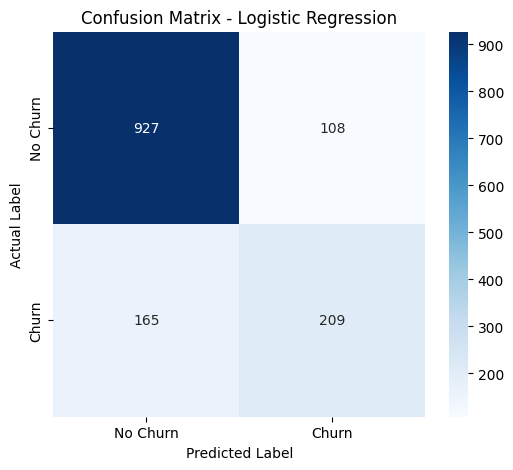

In [52]:
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Churn', 'Churn'],
    yticklabels=['No Churn', 'Churn']
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

**ROC Curve Analysis - Logistic Regression**

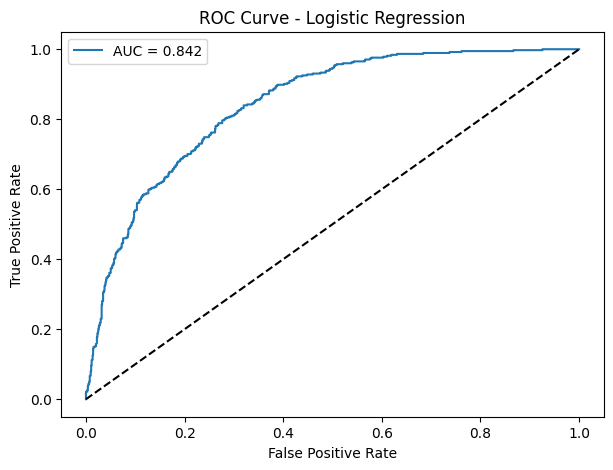

In [53]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.3f}")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

DataFrame of

**Summary of Logistic Regression Results**

In [54]:
import pandas as pd

results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Score": [
        accuracy_log,
        precision_log,
        recall_log,
        f1_log,
        roc_auc_log
    ]
})

results

,Metric,Score
0,Accuracy,0.806246
1,Precision,0.659306
2,Recall,0.558824
3,F1 Score,0.604920
4,ROC-AUC,0.842171


**Logistic Regression Evaluation Metrics Visualization**

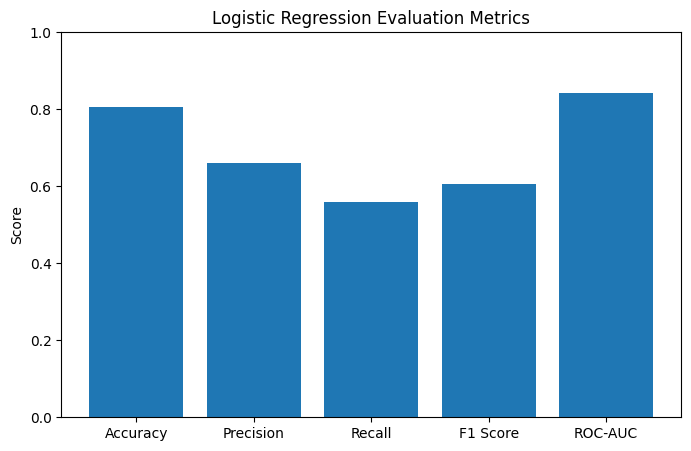

In [55]:
plt.figure(figsize=(8,5))

plt.bar(results["Metric"], results["Score"])

plt.ylim(0,1)

plt.title("Logistic Regression Evaluation Metrics")

plt.ylabel("Score")

plt.show()

**The Logistic Regression model achieved approximately 81% accuracy. It correctly classified 927 non-churning customers and identified 209 customers at risk of churn. However, it missed 165 actual churners, resulting in a churn recall of 56%. This model serves as a strong baseline and motivates the evaluation of more advanced models such as Decision Tree and Random Forest.**

**## 9. Decision Tree Classifier**

A Decision Tree model is trained to capture non-linear relationships between customer characteristics and churn.

In [56]:
from sklearn.tree import DecisionTreeClassifier

In [57]:
dt_model=DecisionTreeClassifier(random_state=42)

In [58]:
dt_model.fit(X_train,y_train)

DecisionTreeClassifier(random_state=42)

In [59]:
y_pred_dt=dt_model.predict(X_test)
y_prob_dt=dt_model.predict_proba(X_test)[:,1]

In [60]:
print("Training Accuracy:", dt_model.score(X_train, y_train))
print("Testing Accuracy:", dt_model.score(X_test, y_test))

Training Accuracy: 0.9980475683351083
Testing Accuracy: 0.7253371185237757


**Performance Metrics of Decision Tree**

---



In [61]:
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
roc_auc_dt = roc_auc_score(y_test, y_prob_dt)

print(f"Accuracy : {accuracy_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall   : {recall_dt:.4f}")
print(f"F1 Score : {f1_dt:.4f}")
print(f"ROC-AUC  : {roc_auc_dt:.4f}")

Accuracy : 0.7253
Precision: 0.4825
Recall   : 0.4786
F1 Score : 0.4805
ROC-AUC  : 0.6460


**Confusion Matrix Of Decision Tree**

In [62]:
cm_dt = confusion_matrix(y_test, y_pred_dt)
print(cm_dt)

[[843 192]
 [195 179]]


**Classification Report Of Decision Tree**

In [63]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.81      0.81      0.81      1035
           1       0.48      0.48      0.48       374

    accuracy                           0.73      1409
   macro avg       0.65      0.65      0.65      1409
weighted avg       0.72      0.73      0.72      1409



**The baseline Decision Tree achieved nearly 100% training accuracy but only 72.5% testing accuracy, indicating severe overfitting. Compared to Logistic Regression, it performed worse across Accuracy, Precision, Recall, F1-score, and ROC-AUC. These results highlight the importance of controlling tree complexity or using ensemble methods such as Random Fores**t

**## 10. Random Forest Classifier**

Random Forest combines multiple decision trees to improve prediction performance and reduce overfitting.

In [64]:
from sklearn.ensemble import RandomForestClassifier

In [65]:
rf_model = RandomForestClassifier(
    random_state=42
)

In [66]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [67]:
y_pred_rf = rf_model.predict(X_test)

y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [68]:
print("Training Accuracy:", rf_model.score(X_train, y_train))
print("Testing Accuracy:", rf_model.score(X_test, y_test))

Training Accuracy: 0.9980475683351083
Testing Accuracy: 0.7849538679914834


**Performance Metrics Of Random Forest**

In [69]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print(f"Accuracy : {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall   : {recall_rf:.4f}")
print(f"F1 Score : {f1_rf:.4f}")
print(f"ROC-AUC  : {roc_auc_rf:.4f}")

Accuracy : 0.7850
Precision: 0.6187
Recall   : 0.4947
F1 Score : 0.5498
ROC-AUC  : 0.8248


**Confusion Matrix of Random Forest**

In [70]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
print(cm_rf)

[[921 114]
 [189 185]]


**Random Forest Hyperparameter Optimization**

GridSearchCV is used to find the optimal combination of Random Forest hyperparameters. Multiple parameter combinations are evaluated using cross-validation, and the model with the best F1-score is selected for improved performance.

In [71]:
from sklearn.model_selection import GridSearchCV
param_grid={'n_estimators':[100,200],'max_depth':[5,10,None],'min_samples_split':[2,5],'min_samples_leaf':[1,2]}
grid_search=GridSearchCV(estimator=RandomForestClassifier(random_state=42),param_grid=param_grid,cv=5,scoring='f1',n_jobs=-1)
grid_search.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, None], 'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='f1')

In [72]:
grid_search.best_params_

{'max_depth': 10,
 'min_samples_leaf': 2,
 'min_samples_split': 5,
 'n_estimators': 100}

In [73]:
grid_search.best_score_

np.float64(0.570639369126033)

In [93]:
best_rf = grid_search.best_estimator_

In [75]:
y_pred = best_rf.predict(X_test)

In [76]:
y_prob = best_rf.predict_proba(X_test)[:, 1]

**Performance Evaluation After Hyperparameter Tuning**

In [77]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy_best = accuracy_score(y_test, y_pred)
precision_best = precision_score(y_test, y_pred)
recall_best = recall_score(y_test, y_pred)
f1_best = f1_score(y_test, y_pred)
roc_auc_best = roc_auc_score(y_test, y_prob)

print(f"Accuracy : {accuracy_best:.4f}")
print(f"Precision: {precision_best:.4f}")
print(f"Recall   : {recall_best:.4f}")
print(f"F1 Score : {f1_best:.4f}")
print(f"ROC-AUC  : {roc_auc_best:.4f}")

Accuracy : 0.8070
Precision: 0.6747
Recall   : 0.5267
F1 Score : 0.5916
ROC-AUC  : 0.8426


In [78]:
print("Training Accuracy:", best_rf.score(X_train, y_train))
print("Testing Accuracy:", best_rf.score(X_test, y_test))

Training Accuracy: 0.8549875754348598
Testing Accuracy: 0.8069552874378992


**Confusion Matrix After Hyperparameter Tuning**

In [79]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[940  95]
 [177 197]]


**Heatmap Of Confusion Matrix After Hyperparameter Tuning**

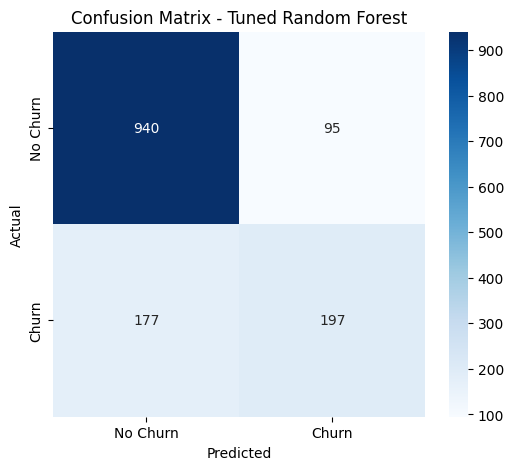

In [80]:
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Churn', 'Churn'],
    yticklabels=['No Churn', 'Churn']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Tuned Random Forest")
plt.show()

**Classification Report After Hyperparameter Tuning**

In [81]:

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.67      0.53      0.59       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409



**ROC Curve - Tuned Random Forest Model**

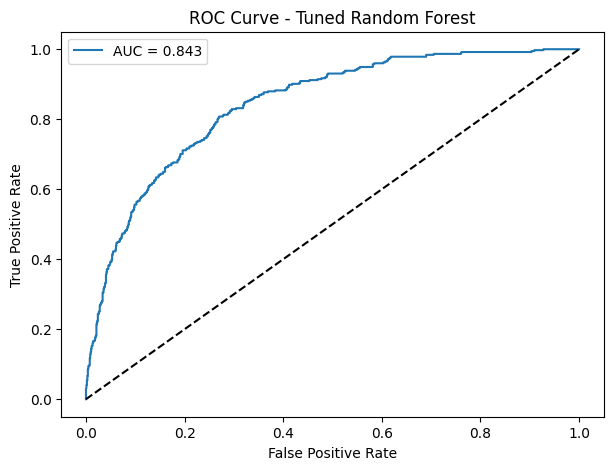

In [82]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_best:.3f}")
plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tuned Random Forest")
plt.legend()
plt.show()

**Comparison**

Different models are compared using accuracy, precision, recall, F1-score, ROC-AUC, and confusion matrices.

In [83]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Tuned Random Forest"
    ],
    "Accuracy": [
        accuracy_log,
        accuracy_dt,
        accuracy_rf,
        accuracy_best
    ],
    "Precision": [
        precision_log,
        precision_dt,
        precision_rf,
        precision_best
    ],
    "Recall": [
        recall_log,
        recall_dt,
        recall_rf,
        recall_best
    ],
    "F1 Score": [
        f1_log,
        f1_dt,
        f1_rf,
        f1_best
    ],
    "ROC-AUC": [
        roc_auc_log,
        roc_auc_dt,
        roc_auc_rf,
        roc_auc_best
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.806246,0.659306,0.558824,0.604920,0.842171
1,Decision Tree,0.725337,0.482480,0.478610,0.480537,0.646047
2,Random Forest,0.784954,0.618729,0.494652,0.549777,0.824842
3,Tuned Random Forest,0.806955,0.674658,0.526738,0.591592,0.842609


**our machine learning models were evaluated for customer churn prediction. The Decision Tree suffered from severe overfitting and produced the weakest performance. Random Forest improved upon the Decision Tree, and hyperparameter tuning further increased its Accuracy, Precision, and ROC-AUC. Logistic Regression achieved the highest Recall and F1-score while maintaining nearly the same Accuracy as the tuned Random Forest. Overall, both Logistic Regression and the Tuned Random Forest performed strongly, with the final model selection depending on whether the business prioritizes identifying more churning customers (Recall) or reducing false churn predictions (Precision).**

**## 12. Feature Importance Analysis**

Feature importance is analyzed to identify which customer attributes contribute most to churn prediction.

In [84]:
feature_importance=pd.DataFrame({'Features':X_train.columns,'Importance':best_rf.feature_importances_})
feature_importance.head()

,Features,Importance
0,SeniorCitizen,0.013338
1,tenure,0.192183
2,MonthlyCharges,0.119614
3,TotalCharges,0.153011
4,gender_Male,0.014295


In [85]:
feature_importance=feature_importance.sort_values(by='Importance',ascending=False)
feature_importance.head(10)

,Features,Importance
1,tenure,0.192183
3,TotalCharges,0.153011
2,MonthlyCharges,0.119614
10,InternetService_Fiber optic,0.066136
28,PaymentMethod_Electronic check,0.060546
25,Contract_Two year,0.058973
13,OnlineSecurity_Yes,0.043119
24,Contract_One year,0.032222
19,TechSupport_Yes,0.027942
26,PaperlessBilling_Yes,0.021632


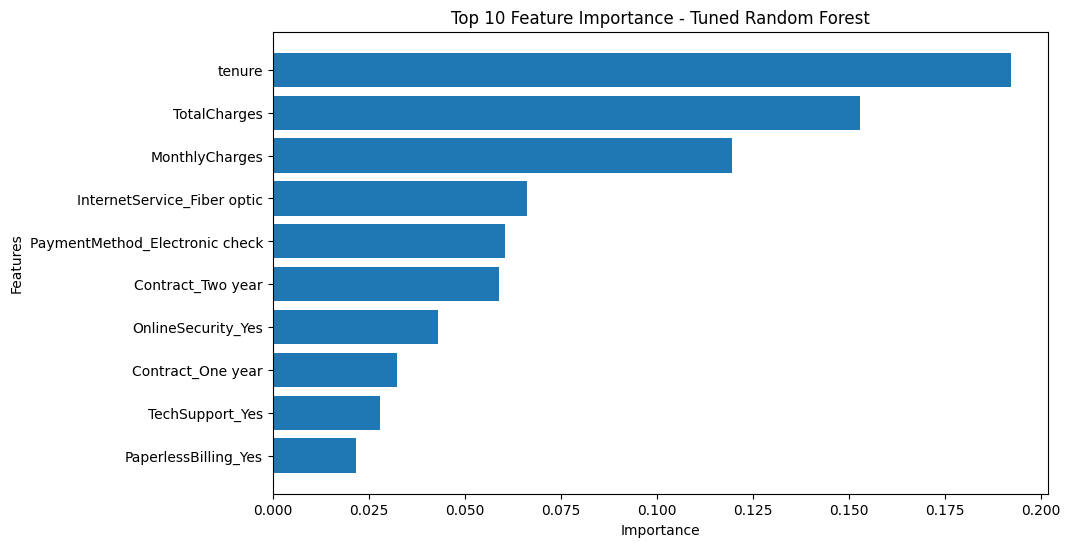

In [86]:
plt.figure(figsize=(10,6))
plt.barh(feature_importance['Features'][:10],feature_importance['Importance'][:10])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Top 10 Feature Importance - Tuned Random Forest")

plt.show()


**Insight 1**

Tenure is the strongest predictor of churn.

**Recommendation**:

Focus retention campaigns on new customers during their first year.
Offer welcome discounts or loyalty rewards.
**Insight 2**

Customers with high Monthly Charges are more likely to churn.

**Recommendation:**

Introduce discounted bundles.
Offer personalized pricing for high-bill customers.

**Insight 3**

Contract type has a major impact.

Both One-year and Two-year contracts appear among the most important features.

**Recommendation**:

Encourage month-to-month customers to switch to longer-term contracts through incentives.

**Insight 4**

Fiber optic customers churn more frequently.

**Recommendation:**

Investigate customer satisfaction.
Improve service quality or pricing for fiber plans.

**Insight 5**

Customers using Online Security and Tech Support are more loyal.

**Recommendation:**

Promote these services to new customers.
Bundle them with internet packages.

**Model Selection For Customer Churn Prediction**

**Using a tuned Random Forest, I analyzed feature importance to identify the factors most associated with customer churn. The most influential features were tenure, TotalCharges, and MonthlyCharges, followed by contract type and internet service type. This indicates that newer customers, customers with higher monthly costs, and customers on month-to-month contracts are at greater risk of churning. These findings can help the company target retention campaigns more effectively**

**logistic Regression achieved the highest Recall (0.559) and F1-score (0.605), making it effective at identifying customers who are likely to churn. However, the Tuned Random Forest achieved the highest Accuracy (80.70%), Precision (67.47%), and ROC-AUC (0.843). Since the differences between the two models were small, the Tuned Random Forest was selected for deployment due to its stronger overall performance and its ability to provide feature importance for business insights.**

**Saving the Trained Model and Preprocessing Objects**

In [88]:
import pickle
with open("churn_model.pkl", "wb") as file:
    pickle.dump(best_rf, file, protocol=4)

with open("scaler.pkl", "wb") as file:
    pickle.dump(scaler, file, protocol=4)
feature_columns=X_train.columns.tolist()


with open("feature_columns.pkl", "wb") as file:
    pickle.dump(feature_columns, file, protocol=4)

In [92]:
from google.colab import files

files.download("churn_model.pkl")
files.download("scaler.pkl")
files.download("feature_columns.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [89]:
X_train[['tenure','MonthlyCharges','TotalCharges']].describe()

,tenure,MonthlyCharges,TotalCharges
count,5.634000e+03,5.634000e+03,5.634000e+03
mean,-1.008935e-17,-2.402527e-16,2.522338e-17
std,1.000089e+00,1.000089e+00,1.000089e+00
min,-1.322329e+00,-1.544028e+00,-1.008922e+00
25%,-9.559779e-01,-9.711977e-01,-8.321009e-01
50%,-1.418632e-01,1.848336e-01,-3.968446e-01
75%,9.164859e-01,8.319124e-01,6.741944e-01
max,1.608483e+00,1.785939e+00,2.801869e+00


In [90]:
df[['tenure','MonthlyCharges','TotalCharges']].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


**## 13. Final Conclusion and Business Insights**

This project demonstrates a complete machine learning pipeline for customer churn prediction.

Key findings:
- Customers with shorter tenure are more likely to churn.
- Month-to-month contract customers show higher churn rates.
- Lack of support services increases churn probability.
- Customer behavior and service-related features are important predictors.

The developed model can help telecom companies identify high-risk customers and design targeted retention strategies.